In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style = "whitegrid")

In [32]:
df = pd.read_csv(
    "../data/processed/loan_2018q2_clean.csv",
    parse_dates=["issue_d", "earliest_cr_line"],
    low_memory=False
)



### Task 3

#### NPL Target Definition

Following the task definition, loans with statuses `Late (16-30 days)`, `Late (31-120 days)`, `Default`, and `Charged Off` are treated as non-performing. All other loan statuses are treated as performing for this snapshot.

In [ ]:
npl_statuses = [
    "Late (16-30 days)",
    "Late (31-120 days)",
    "Default",
    "Charged Off"
]

df["target_npl"] = df["loan_status"].isin(npl_statuses).astype(int)
df["non_performing"] = df["target_npl"]

#### Numerical Feature Exploration

In [ ]:
display(
  df["non_performing"]
        .value_counts(normalize=True)
        .mul(100)
        )



non_performing
0   96.27
1    3.73
Name: proportion, dtype: float64

In [ ]:
numeric_cols = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "emp_length",
    "revol_util",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "total_acc",
    "credit_history_months",
    "loan_to_income",
    "installment_to_income_pct"
]

numeric_comparison = (
  df.groupby("non_performing")[numeric_cols]
  .agg(["mean", "median"])
)

numeric_comparison.T

non_performing                          0        1
loan_amnt                 mean   15858.89 17195.89
                          median 13200.00 15000.00
term                      mean      43.13    45.15
                          median    36.00    36.00
int_rate                  mean      12.42    16.13
                          median    11.98    15.49
installment               mean     461.10   515.09
                          median   380.28   445.57
annual_inc                mean   78791.50 75407.84
                          median 65000.00 61100.00
dti                       mean      19.26    19.92
                          median    17.37    17.78
emp_length                mean       5.98     5.63
                          median     6.00     5.00
revol_util                mean      43.42    43.53
                          median    41.60    42.10
delinq_2yrs               mean       0.23     0.28
                          median     0.00     0.00
inq_last_6mths            mean       0.44     0.64
                          median     0.00     0.00
open_acc                  mean      11.46    10.91
                          median    10.00    10.00
pub_rec                   mean       0.13     0.14
                          median     0.00     0.00
total_acc                 mean      22.50    21.67
                          median    20.00    20.00
credit_history_months     mean     191.74   178.73
                          median   173.00   162.00
loan_to_income            mean       0.72     1.94
                          median     0.20     0.24
installment_to_income_pct mean      22.88    90.08
                          median     7.12     8.62

In [35]:
df["int_rate_bucket"] = pd.cut(
    df["int_rate"],
    bins=[0, 8, 12, 16, 20, 25, 35],
    labels=["<=8", "8-12", "12-16", "16-20", "20-25", "25+"]
)

df["dti_bucket"] = pd.cut(
    df["dti"],
    bins=[-1, 10, 20, 30, 40, 100, np.inf],
    labels=["<=10", "10-20", "20-30", "30-40", "40-100", "100+"]
)

df["income_bucket"] = pd.cut(
    df["annual_inc"],
    bins=[-1, 0, 25000, 50000, 75000, 100000, 200000, np.inf],
    labels=["zero", "<=25k", "25-50k", "50-75k", "75-100k", "100-200k", "200k+"]
)

df["loan_amnt_bucket"] = pd.cut(
    df["loan_amnt"],
    bins=[0, 5000, 10000, 15000, 20000, 30000, 40000],
    labels=["<=5k", "5-10k", "10-15k", "15-20k", "20-30k", "30-40k"]
)

df["loan_to_income_bucket"] = pd.cut(
    df["loan_to_income"],
    bins=[0, 0.1, 0.2, 0.3, 0.5, 1, np.inf],
    labels=["<=10%", "10-20%", "20-30%", "30-50%", "50-100%", "100%+"]
)

df["installment_income_bucket"] = pd.cut(
    df["installment_to_income_pct"],
    bins=[0, 3, 5, 8, 10, 15, np.inf],
    labels=["<=3%", "3-5%", "5-8%", "8-10%", "10-15%", "15%+"]
)

df["revol_util_bucket"] = pd.cut(
    df["revol_util"],
    bins=[-1, 20, 40, 60, 80, 100, np.inf],
    labels=["<=20", "20-40", "40-60", "60-80", "80-100", "100+"]
)

df["credit_history_bucket"] = pd.cut(
    df["credit_history_months"],
    bins=[0, 60, 120, 180, 240, 360, np.inf],
    labels=["<=5y", "5-10y", "10-15y", "15-20y", "20-30y", "30y+"]
)

df["emp_length_bucket"] = pd.cut(
    df["emp_length"],
    bins=[-1, 0, 2, 5, 9, 10],
    labels=["<1y", "1-2y", "3-5y", "6-9y", "10y+"]
)

df["delinq_2yrs_bucket"] = pd.cut(
    df["delinq_2yrs"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)

df["inq_last_6mths_bucket"] = pd.cut(
    df["inq_last_6mths"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)



In [ ]:
def npl_rate_by_bucket(bucket_col):
    return (
        df.groupby(bucket_col, observed=True)["non_performing"]
        .agg(loan_count="size", npl_rate="mean")
        .assign(npl_rate_pct=lambda x: x["npl_rate"] * 100)
        .drop(columns="npl_rate")
    )



In [37]:
bucket_cols = [
    "int_rate_bucket",
    "dti_bucket",
    "income_bucket",
    "loan_amnt_bucket",
    "loan_to_income_bucket",
    "installment_income_bucket",
    "revol_util_bucket",
    "credit_history_bucket",
    "emp_length_bucket",
    "delinq_2yrs_bucket",
    "inq_last_6mths_bucket"
]

for col in bucket_cols:
    print(col)
    display(npl_rate_by_bucket(col))


int_rate_bucket


,loan_count,npl_rate_pct
int_rate_bucket,,
<=8,29703,1.01
8-12,37474,2.43
12-16,33140,3.99
16-20,18525,6.43
20-25,8694,8.87
25+,3236,11.90


dti_bucket


,loan_count,npl_rate_pct
dti_bucket,,
<=10,27720,4.21
10-20,50464,3.32
20-30,35338,3.57
30-40,13146,4.52
40-100,3384,4.49
100+,394,5.08


income_bucket


...

,loan_count,npl_rate_pct
emp_length_bucket,,
<1y,8899,4.16
1-2y,20928,3.81
3-5y,27703,3.89
6-9y,18959,3.41
10y+,43815,3.23


delinq_2yrs_bucket


,loan_count,npl_rate_pct
delinq_2yrs_bucket,,
0,111253,3.63
1,13626,4.10
2,3450,4.78
3+,2443,4.79


inq_last_6mths_bucket


,loan_count,npl_rate_pct
inq_last_6mths_bucket,,
0,87245,3.11
1,31418,4.61
2,9357,5.65
3+,2752,7.19


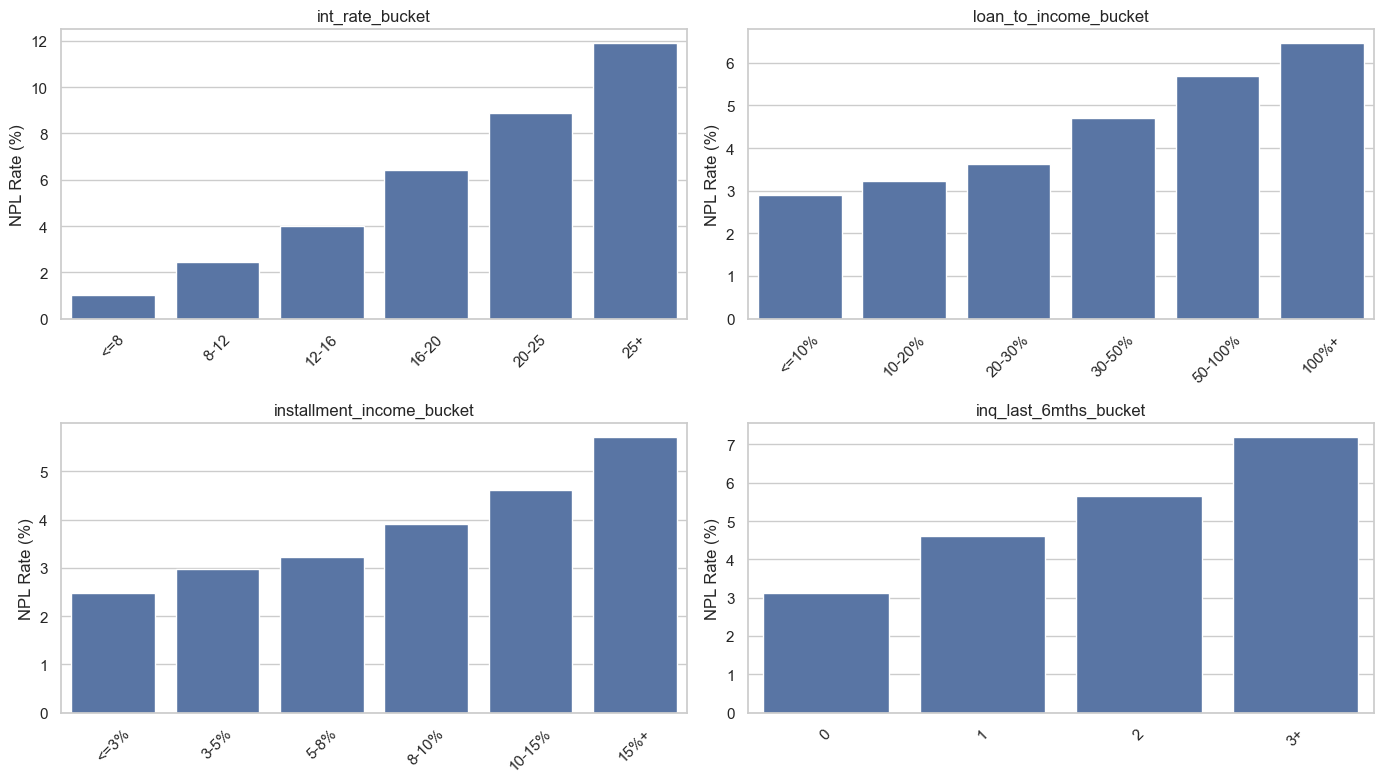

In [38]:
strong_bucket_cols = [
    "int_rate_bucket",
    "loan_to_income_bucket",
    "installment_income_bucket",
    "inq_last_6mths_bucket"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, strong_bucket_cols):
    data = npl_rate_by_bucket(col).reset_index()

    sns.barplot(
        data=data,
        x=col,
        y="npl_rate_pct",
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("NPL Rate (%)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

##### Observations

The strongest potential NPL indicators are `int_rate`, affordability ratios, and recent credit inquiries.

`int_rate` shows the clearest monotonic relationship with NPL rate. Loans with rates <=8% have an NPL rate around 1.0%, while loans above 25% have an NPL rate around 11.9%. This is the strongest single pattern, although interest rate may already reflect internal risk pricing.

Affordability variables also show strong separation. `loan_to_income` rises from about 2.9% NPL for loans <=10% of income to about 6.5% for loans above annual income. `installment_to_income_pct` similarly rises from about 2.5% to 5.7%, suggesting that larger repayment burden relative to income is associated with higher NPL risk.

Recent credit inquiries are another strong signal. Borrowers with no inquiries in the last 6 months have around 3.1% NPL, while borrowers with 3+ inquiries have around 7.2%. This suggests recent credit-seeking behavior may be useful for identifying riskier loans.

Moderate predictors include `annual_inc`, `loan_amnt`, `credit_history_months`, `emp_length`, and `delinq_2yrs`. Lower income, larger loan amounts, shorter credit history, shorter employment history, and prior delinquencies are all associated with somewhat higher NPL rates, but the separation is weaker than for interest rate or affordability ratios.

`dti` is weaker than expected. NPL rates vary only modestly across most DTI buckets, and the pattern is not fully monotonic. This suggests DTI may still be useful, but it is not one of the strongest standalone predictors in this sample.

`revol_util` also shows limited separation across most buckets. Only the 100%+ utilization group has a noticeably higher NPL rate, but that group is very small, so it should be interpreted carefully.

Variables such as `pub_rec`, `open_acc`, and `total_acc` do not show strong standalone separation. They may still help in combination with other variables, but based on bucket analysis alone they are weaker predictors.

Summary
Strong:
- `int_rate`
- `loan_to_income`
- `installment_to_income_pct`
- `inq_last_6mths`

Moderate:
- `annual_inc`
- `loan_amnt`
- `credit_history_months`
- `emp_length`
- `delinq_2yrs`

Weak:
- `dti`
- `revol_util`
- `pub_rec`
- `open_acc`
- `total_acc`

#### Categorical Feature Exploration

In [39]:
(
    pd.crosstab(
        df["grade"],
        df["non_performing"],
        normalize="index"
    )
    .mul(100)
    .round(2)[1]
    .rename("npl_rate_pct")
)


grade
A    1.04
B    2.59
C    4.43
D    7.45
E   10.44
F   12.78
G   14.29
Name: npl_rate_pct, dtype: float64

In [40]:
(
    pd.crosstab(
        df["sub_grade"],
        df["non_performing"],
        normalize="index"
    )
    .mul(100)
    .round(2)[1]
    .rename("npl_rate_pct")
)


sub_grade
A1    0.58
A2    0.68
A3    1.01
A4    1.27
A5    1.57
B1    2.05
B2    2.07
B3    2.62
B4    2.73
B5    3.41
C1    3.68
C2    3.95
C3    4.06
C4    4.97
C5    5.72
D1    6.22
D2    7.24
D3    7.04
D4    7.50
D5    9.81
E1    8.50
E2    7.92
E3   11.28
E4   10.20
E5   12.11
F1   14.35
F2   11.59
F3   10.71
F4    9.09
F5   12.50
G1   16.88
G2    0.00
G3    0.00
G4    0.00
G5    0.00
Name: npl_rate_pct, dtype: float64

In [41]:
(
    pd.crosstab(
        df["verification_status"],
        df["non_performing"],
        normalize="index"
    )
    .mul(100)
    .round(2)[1]
    .rename("npl_rate_pct")
)


verification_status
Not Verified      2.66
Source Verified   3.90
Verified          5.35
Name: npl_rate_pct, dtype: float64

In [42]:
# removing ANY, very low sample/noise
no_any_home_ownership = df[df["home_ownership"] != "ANY"]

(
    pd.crosstab(
        no_any_home_ownership["home_ownership"],
        no_any_home_ownership["non_performing"],
        normalize="index"
    )
    .mul(100)
    .round(2)[1]
    .rename("npl_rate_pct")
)


home_ownership
MORTGAGE   3.04
OWN        4.15
RENT       4.41
Name: npl_rate_pct, dtype: float64

In [43]:
display(
    pd.crosstab(
        df["purpose"],
        df["non_performing"],
        normalize="index"
    )
    .mul(100)
    .round(2)[1]
    .rename("npl_rate_pct")
    .sort_values(ascending=False)
)

display(
    pd.crosstab(
        df["purpose"],
        df["non_performing"]
    )
)


purpose
small_business       8.05
medical              5.92
moving               5.90
major_purchase       5.31
vacation             5.11
house                4.87
other                4.75
car                  4.20
renewable_energy     4.17
home_improvement     3.87
debt_consolidation   3.85
credit_card          2.43
Name: npl_rate_pct, dtype: float64

non_performing,0,1
purpose,,
car,1461,64
credit_card,32025,797
debt_consolidation,61669,2472
home_improvement,9278,374
house,2131,109
major_purchase,3563,200
medical,1842,116
moving,877,55
other,10772,537


In [44]:
(
    pd.crosstab(
        df["term"],
        df["non_performing"],
        normalize="index"
    )
    .mul(100)
    .round(2)[1]
    .rename("npl_rate_pct")
)


term
36.00   3.30
60.00   4.74
Name: npl_rate_pct, dtype: float64

In [45]:
(
    pd.crosstab(
        df["application_type"],
        df["non_performing"],
        normalize="index"
    )
    .mul(100)
    .round(2)[1]
    .rename("npl_rate_pct")
)


application_type
Individual   3.60
Joint App    4.59
Name: npl_rate_pct, dtype: float64

Categorical analysis suggests that `grade` and `sub_grade` are the strongest categorical indicators of NPL risk. NPL rates increase consistently from grade A to grade G, showing that assigned risk grades align strongly with observed non-performance.

`verification_status`, `purpose`, and `term` show moderate separation. Verified loans have higher NPL rates than non-verified loans, likely because income verification is more common for higher-risk applications. Loan purpose also matters, with credit card refinancing showing relatively low NPL rates and small business, medical, and moving loans showing higher rates. Longer 60-month loans have higher NPL rates than 36-month loans.

`home_ownership` and `application_type` show weaker standalone separation. Mortgage borrowers perform somewhat better than renters or owners, and joint applications have slightly higher NPL rates than individual applications, but the differences are smaller than for grade, sub-grade, interest rate, or affordability variables.

Strong:
- `grade`
- `sub_grade`

Moderate:
- `verification_status`
- `purpose`
- `term`

Weak:
- `home_ownership`
- `application_type`

#### Final Variable Recommendation

Based on the numerical and categorical analysis, the strongest variables for identifying non-performing loans are `grade`, `sub_grade`, `int_rate`, `loan_to_income`, `installment_to_income_pct`, and `inq_last_6mths`. These variables show the clearest separation in NPL rates.

Moderately useful variables include `annual_inc`, `loan_amnt`, `credit_history_months`, `emp_length`, `delinq_2yrs`, `verification_status`, `purpose`, and `term`. These variables show meaningful but weaker separation.

Weaker standalone variables include `dti`, `revol_util`, `pub_rec`, `open_acc`, `total_acc`, `home_ownership`, and `application_type`. They may still help in combination with other variables, but their individual separation is limited in this sample.

Important note: `grade`, `sub_grade`, and `int_rate` likely already include risk assessment information, so they are strong predictors but may partly encode the lender's own credit decisioning process.